# Random-walk-environment


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- 1. The Environment Setup ---
# We represent the hallway as numbers. 
# 0 = Left Door (Lose), 6 = Right Door (Win)
# 1, 2, 3, 4, 5 = The tiles A, B, C, D, E
STATES = [1, 2, 3, 4, 5]
TRUE_VALUES = [1/6, 2/6, 3/6, 4/6, 5/6]
START_STATE = 3

In [3]:
def run_episode():
    """Simulates one full walk through the hallway until you win or lose."""
    state = START_STATE
    trajectory = [state] # Remember where we stepped
    
    # Keep walking until we fall out a door (state 0 or state 6)
    while state != 0 and state != 6:
        if np.random.rand() < 0.5:
            state -= 1  # Step Left
        else:
            state += 1  # Step Right
        trajectory.append(state)
        
    # We only get a reward if we hit the Right Door (6)
    reward = 1.0 if state == 6 else 0.0
    
    # Return the tiles we visited (excluding the door) and the final reward
    return trajectory[:-1], reward

In [4]:
# --- 2. The Agent Learning (Monte Carlo) ---
episodes = 100
# The agent starts completely blind, guessing every tile is a 50/50 chance
estimated_values = {s: 0.5 for s in STATES}
alpha = 0.1 # Learning rate

for _ in range(episodes):
    visited_states, reward = run_episode()
    
    # Look back at every tile we stepped on during this walk.
    # Update our estimated value using the formula: New = Old + Alpha * (Reward - Old)
    for state in visited_states:
        estimated_values[state] += alpha * (reward - estimated_values[state])

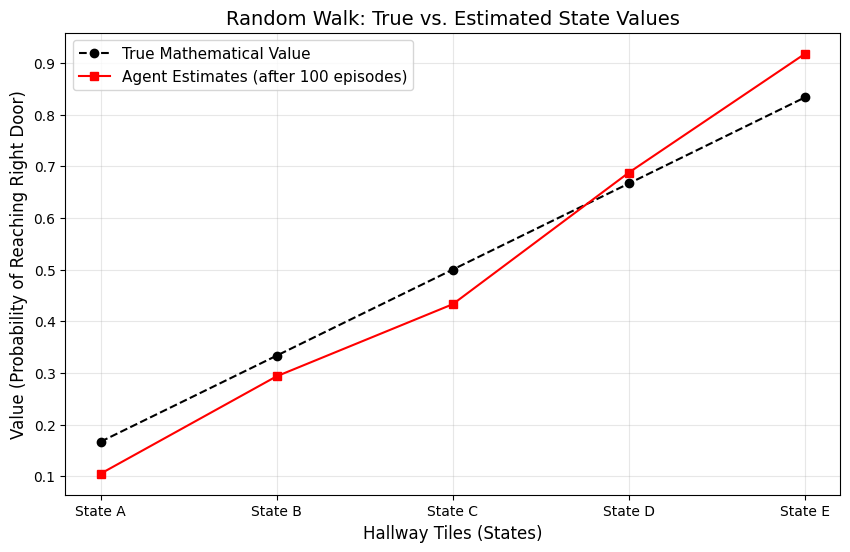

In [5]:
# --- 3. The Visual Graph (Deliverable) ---
plt.figure(figsize=(10, 6))

# Plot the True Mathematical Values (Black dashed line)
plt.plot(STATES, TRUE_VALUES, marker='o', color='black', linestyle='--', 
         label='True Mathematical Value')

# Plot the Agent's Learned Estimates (Red line)
plt.plot(STATES, [estimated_values[s] for s in STATES], marker='s', color='red', 
         label=f'Agent Estimates (after {episodes} episodes)')

plt.title("Random Walk: True vs. Estimated State Values", fontsize=14)
plt.xticks(STATES, ['State A', 'State B', 'State C', 'State D', 'State E'])
plt.xlabel("Hallway Tiles (States)", fontsize=12)
plt.ylabel("Value (Probability of Reaching Right Door)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.show()